<a href="https://colab.research.google.com/github/Aarjoo2603/projects/blob/main/Week6_Aarjoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


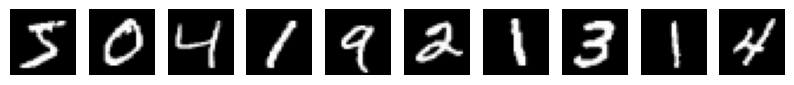

In [5]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [7]:
x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test, (len(x_test),28,28,1))

print(x_train.shape)

(60000, 28, 28, 1)


In [8]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

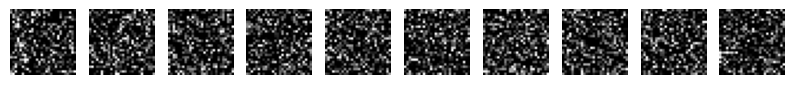

In [9]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [10]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img, decoded)

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [13]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 279ms/step - loss: 0.0147 - val_loss: 0.0041
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 275ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 275ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 274ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 275ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 274ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 277ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 272ms/step - loss: 0.0040 - val_loss: 0.0040


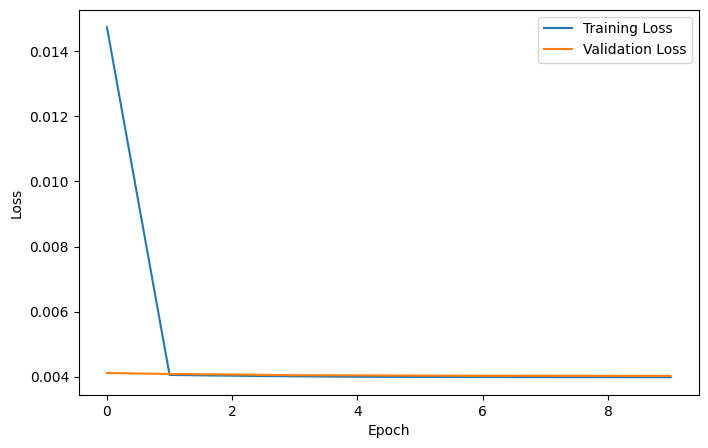

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


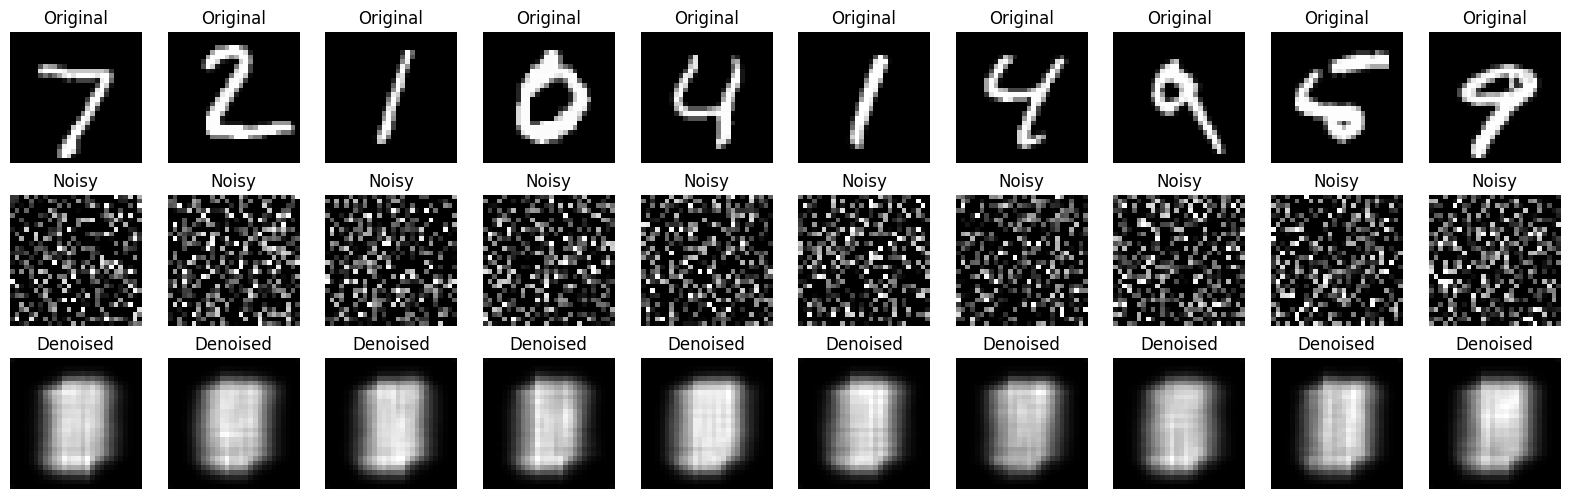

In [16]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,n,i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

In [17]:
autoencoder.save("mnist_autoencoder.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
print("Conclusion")
print("The Autoencoder model was successfully trained on the MNIST dataset.")
print("The model learned to remove noise from handwritten digit images.")
print("The denoised images closely resemble the original images.")

Conclusion
The Autoencoder model was successfully trained on the MNIST dataset.
The model learned to remove noise from handwritten digit images.
The denoised images closely resemble the original images.
